# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [2]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [3]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
df_missing = df.isnull().mean() * 100
print("Tỷ lệ missing của các cột:\n", df_missing)

# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
leaky = ["alive", "who", "alone", "deck", "embark_town", "class", "adult_male"]
# df = df.drop(columns=...)
df = df.drop(columns=leaky)

# print("Các cột còn lại:", list(df.columns))
print("Các cột còn lại:", df.columns.tolist())

Tỷ lệ missing của các cột:
 survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64
Các cột còn lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

Cột 'alive' chính là bản viết chữ của survived (mang giá trị 0 hoặc 1). Việc đưa cột này vào dữ liệu sẽ gây ra hiện tượng rò rỉ target, đưa sẫn kết quả cho mô hình học.
Khi đó, mô hình sẽ "gian lận" bằng cách chỉ tạo ra một quy tắc học vẹt đơn giản ( nếu alive = yes thì survived = 1) mà không cần quan tâm đến các yếu tố khác như hạng vé, giới tính hay tuổi tác



---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [4]:
# TODO 2: shape, info, describe

print(f"Dataset có {df.shape[0]} dòng và {df.shape[1]} cột.")
print("Biến mục tiêu (target) của bài toán này là cột: 'survived'\n")

print("--- INFO ---")
df.info()

print("\n--- THỐNG KÊ BIẾN SỐ ---")
display(df.describe())

print("\n--- THỐNG KÊ BIẾN PHÂN LOẠI ---")
display(df.describe(include=["object", "category"]))

Dataset có 891 dòng và 8 cột.
Biến mục tiêu (target) của bài toán này là cột: 'survived'

--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    str    
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB

--- THỐNG KÊ BIẾN SỐ ---


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



--- THỐNG KÊ BIẾN PHÂN LOẠI ---


C:\Users\Thái Khôi\AppData\Local\Temp\ipykernel_10008\2756578862.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include=["object", "category"]))


,sex,embarked
count,891,889
unique,2,3
top,male,S
freq,577,644


**Trả lời 2 (biến số vs biến phân loại):**

- *Biến số* : age , fare , sibsp , parch
- *Biến phân loại* : sex , embarked
- *Trường hợp đặc biệt ( lưu bằng số nhưng bản chất là phân loại)*: pclass, survived

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [5]:
# TODO 3: bảng missing (count + %)
missing_count = df.isnull().sum()
missing_percent = (df.isnull().mean() * 100).round(2)
missing_table = pd.DataFrame({"Missing Count": missing_count, "Missing Percent": missing_percent})
missing_table = missing_table[missing_table["Missing Count"] > 0]
print("\n--- BẢNG MISSING ---")
display(missing_table)



--- BẢNG MISSING ---


,Missing Count,Missing Percent
age,177,19.87
embarked,2,0.22


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột | % thiếu | Cách xử lý đề xuất | Lý do |
|---|---|---|---|
| **age** | ~19.87% | Điền giá trị trung vị (`median`) | `age` là đặc trưng dạng số. Việc sử dụng giá trị trung vị (`median`) giúp xử lý dữ liệu khuyết một cách bền vững, tránh được hiện tượng sai lệch thông tin do trung vị không bị ảnh hưởng bởi các giá trị ngoại lệ (outliers). |
| **embarked** | ~0.22% | Điền giá trị xuất hiện nhiều nhất (`mode`) | `embarked` là đặc trưng dạng phân loại. Tỷ lệ thiếu hụt của cột này cực kỳ thấp (chỉ thiếu 2 mẫu hành khách) nên việc áp dụng giá trị yếu vị (`mode`) là giải pháp tối ưu và an toàn nhất. |  

---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [6]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
def dem_outlier_iqr(s):
    # trả về số lượng outlier theo IQR
    s = s.dropna()  
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return ((s < lower_bound) | (s > upper_bound)).sum()

def dem_outlier_zscore(s, nguong=3.0):
    from scipy import stats
    z_scores = np.abs(stats.zscore(s.dropna()))
    return (z_scores > nguong).sum()

# for col in ["age", "fare"]:
for col in ["age", "fare"]:
    iqr_count = dem_outlier_iqr(df[col])
    zscore_count = dem_outlier_zscore(df[col])
    print(f"Cột '{col}': {iqr_count} outlier theo IQR, {zscore_count} outlier theo Z-score.")

Cột 'age': 11 outlier theo IQR, 2 outlier theo Z-score.
Cột 'fare': 116 outlier theo IQR, 20 outlier theo Z-score.


**Trả lời 4 (quyết định với outlier của `fare`):**

Quyết định: **Giữ lại** toàn bộ các giá trị outlier của cột `fare`. 

**Lý do:** 
1. **Dữ liệu hợp lệ:** Các mức giá vé cao đột biến (như ~512 USD) hoàn toàn không phải là lỗi nhập liệu hay nhiễu, mà đó là dữ liệu thực tế phản ánh giá trị của các vé hạng nhất (First Class) trên tàu Titanic.
2. **Tránh hao hụt thông tin:** Số lượng outlier theo chuẩn IQR là khá lớn (116 mẫu), nếu xóa bỏ (drop) sẽ làm thất thoát một lượng lớn dữ liệu giá trị của bộ dataset. 


---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

Text(0.5, 1.0, 'Distribution of fare')

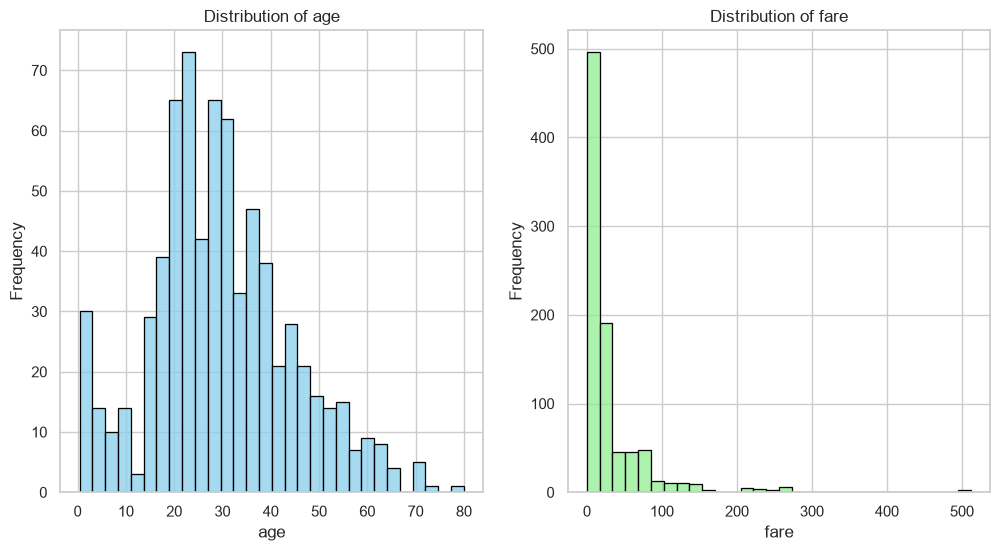

In [7]:
# TODO 5a: Histogram age & fare
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['age'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.xlabel('age')
plt.ylabel('Frequency')
plt.title('Distribution of age')

plt.subplot(1, 2, 2)
sns.histplot(df['fare'].dropna(), bins=30, color='lightgreen', edgecolor='black')
plt.xlabel('fare')
plt.ylabel('Frequency')
plt.title('Distribution of fare')

Text(0, 0.5, 'Fare')

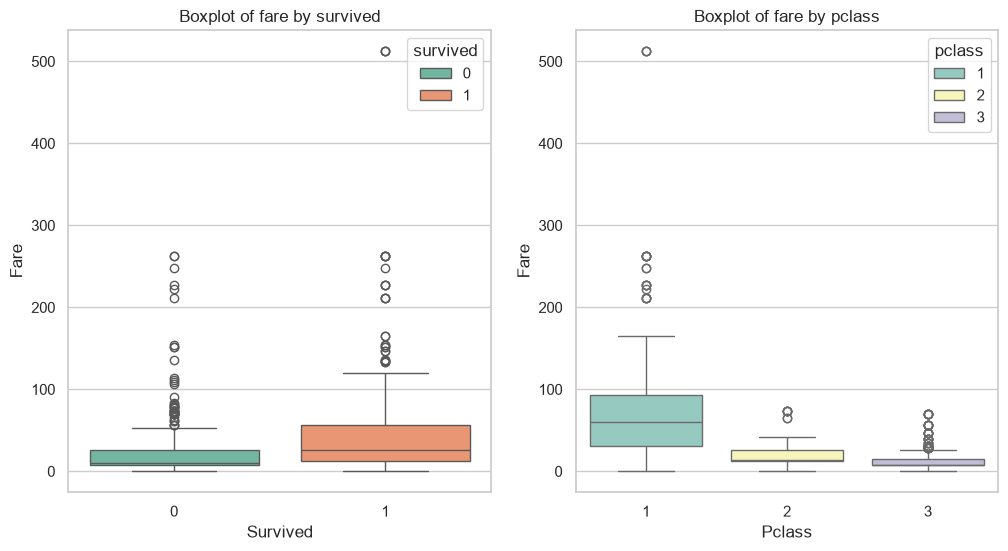

In [8]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='survived', y='fare', data=df, hue='survived', palette='Set2')
plt.title('Boxplot of fare by survived')
plt.xlabel('Survived')
plt.ylabel('Fare')

plt.subplot(1, 2, 2)
sns.boxplot(x='pclass', y='fare', data=df, hue='pclass', palette='Set3')
plt.title('Boxplot of fare by pclass')
plt.xlabel('Pclass')
plt.ylabel('Fare')


Text(0.5, 1.0, 'Survival Rate by Passenger Class')

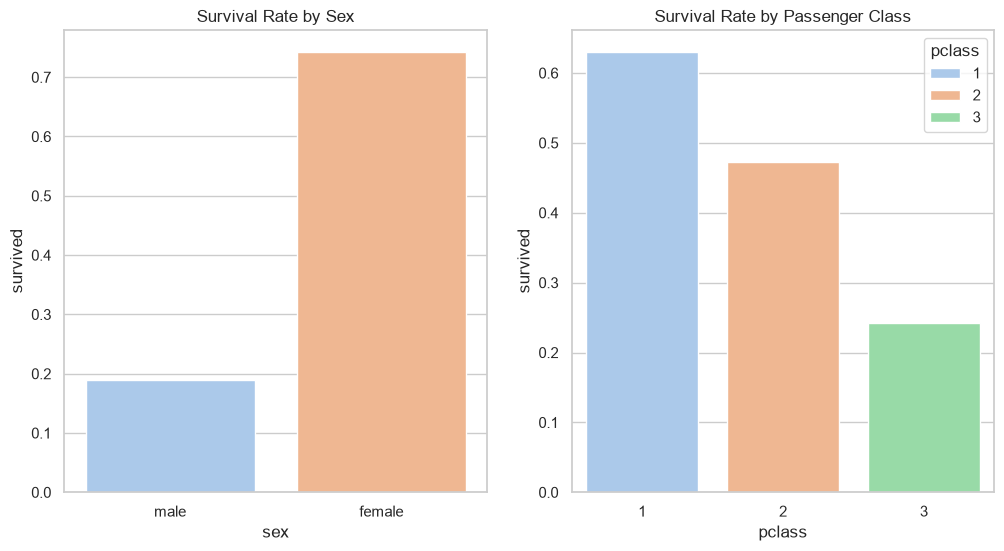

In [9]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.barplot(x='sex', y='survived', data=df, errorbar=None,hue='sex', palette='pastel')
plt.title('Survival Rate by Sex')               

plt.subplot(1, 2, 2)
sns.barplot(x='pclass', y='survived', data=df, errorbar=None, hue='pclass', palette='pastel')
plt.title('Survival Rate by Passenger Class')  


Text(0.5, 1.0, 'Correlation Heatmap')

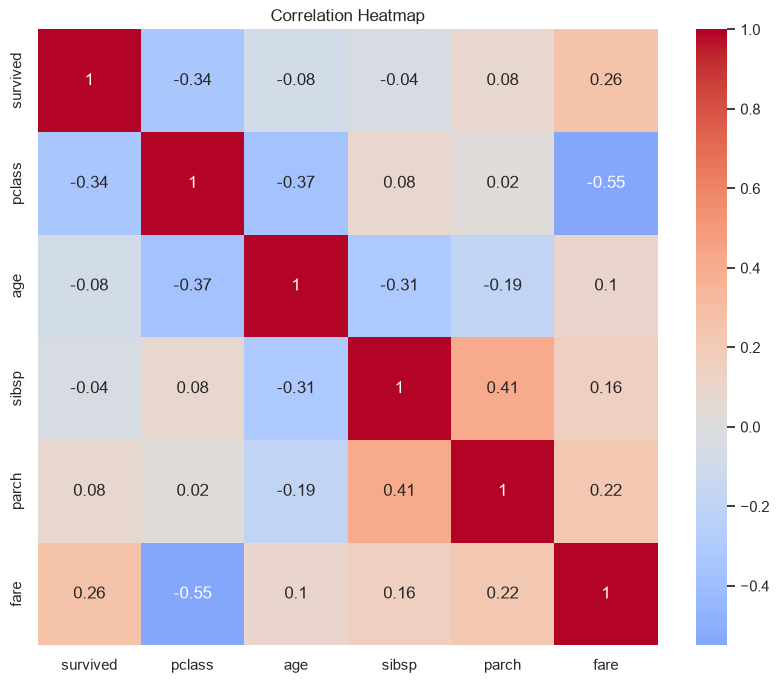

In [10]:
# TODO 5d: Heatmap correlation
plt.figure(figsize=(10, 8))
# Tính ma trận tương quan
corr_matrix = df.corr(numeric_only=True).round(2)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')

**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

1. **Histogram (Phân phối Đơn biến):** 
   - **`age` (Tuổi):** Phân phối có dạng gần chuẩn nhưng hơi lệch phải, tập trung đông đảo nhất ở nhóm thanh niên từ 20 đến 30 tuổi. Có một lượng nhỏ hành khách là trẻ sơ sinh/trẻ em.
   - **`fare` (Giá vé):** Phân phối lệch phải (right-skewed) cực kỳ mạnh. Đại đa số hành khách mua vé ở mức giá rất thấp, chỉ có một số ít mua vé giá rất cao.

2. **Boxplot (Phát hiện Outlier):** 
   - Biểu đồ hộp của `fare` khi chia theo `pclass` xác nhận rằng: Toàn bộ các giá vé cao đột biến (outliers lên tới hơn 512 USD) đều thuộc về nhóm Hạng 1 (First-class). Các hạng 2 và 3 có dải giá vé rất thấp và hẹp. Điều này cho thấy sự phân hóa giai cấp rõ rệt.

3. **Barplot (Mối quan hệ với Nhãn - Survival Rate):**
   - **Theo Giới tính (`sex`):** Tỷ lệ sống sót của nữ giới áp đảo hoàn toàn so với nam giới (~74% so với ~19%), phản ánh chân thực nguyên tắc "Ưu tiên phụ nữ và trẻ em" trong lúc cứu nạn.
   - **Theo Hạng vé (`pclass`):** Tỷ lệ sống sót tỷ lệ thuận với độ giàu có. Hành khách Hạng 1 có cơ hội sống sót cao nhất (~63%), trong khi hành khách Hạng 3 có tỷ lệ sống sót thấp nhất (~24%).

4. **Heatmap (Ma trận tương quan):**
   - Cặp biến `pclass` và `fare` có tương quan âm mạnh nhất ($r \approx -0.55$), hoàn toàn hợp lý vì hạng vé số càng nhỏ (Hạng 1) thì giá vé càng đắt.
   - `survived` có tương quan âm khá rõ với `pclass` ($r \approx -0.34$), củng cố thêm kết luận từ Barplot: Hạng vé càng thấp (số càng to) thì khả năng sống sót càng giảm.
   - `sibsp` và `parch` có tương quan dương ($r \approx 0.41$), cho thấy những hành khách đi cùng anh chị em/vợ chồng thì thường cũng đi cùng cha mẹ/con cái.

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [11]:
# TODO 6: chia train/val/test có stratify
X = df.drop(columns=['survived'])
y = df['survived']

# X_tmp, X_test, y_tmp, y_test = train_test_split(...)
# X_train, X_val, y_train, y_val = train_test_split(...)
X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=15/85, stratify=y_tmp, random_state=42)

# print("Train/Val/Taest:", ...)
# in tỷ lệ survived từng tập
print("Train/Val/Test sizes:", X_train.shape[0], X_val.shape[0], X_test.shape[0])
print("Train survival rate:" , y_train.mean())
print("Validation survival rate:", y_val.mean())
print("Test survival rate:", y_test.mean())


Train/Val/Test sizes: 623 134 134
Train survival rate: 0.38362760834670945
Validation survival rate: 0.3880597014925373
Test survival rate: 0.3805970149253731


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [12]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so  = Pipeline([
    # ("imputer", ...),
    # ("scaler",  ...),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])
pipe_cat = Pipeline([
    # ("imputer", ...),
    # ("onehot",  ...),
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    # ("num", pipe_so,  num_cols),
    # ("cat", pipe_cat, cat_cols),
    # ("ord", "passthrough", ord_cols),
    ("num", pipe_so,  num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols)
])

# preprocess.fit(X_train)               # fit CHỈ trên train
# X_train_t = preprocess.transform(X_train)
# ... transform cho val, test
# print(X_train_t.shape, list(preprocess.get_feature_names_out()))

preprocess.fit(X_train)               
X_train_t = preprocess.transform(X_train)
X_val_t = preprocess.transform(X_val)
X_test_t = preprocess.transform(X_test)

print(X_train_t.shape, list(preprocess.get_feature_names_out()))

(623, 10) ['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**

Việc chỉ gọi hàm `fit` trên tập huấn luyện (`X_train`) là quy tắc bắt buộc để ngăn chặn hiện tượng rò rỉ dữ liệu (Data Leakage) vì 2 lý do chính:
1. **Bảo toàn sự cách ly của tập Test/Val:** Các thông số như trung vị (`median` của SimpleImputer) hoặc khoảng tứ phân vị (`IQR` của RobustScaler) phải được tính toán hoàn toàn dựa trên dữ liệu mà mô hình được phép học (Tập Train). Nếu `fit` trên toàn bộ dữ liệu, thông tin của tập Test/Val sẽ vô tình "rò rỉ" vào quá trình biến đổi, khiến mô hình như được "biết trước đề thi", dẫn đến điểm số đánh giá cao ảo tưởng nhưng thất bại khi thực chiến.
2. **Mô phỏng bài toán thực tế:** Tập Test đại diện cho những hành khách mới mà chúng ta chưa hề có dữ liệu. Trong thực tế, hệ thống chỉ có thể áp dụng các tham số thống kê đã lưu lại từ lịch sử (`X_train`) để `transform` cho những điểm dữ liệu tương lai này.

---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [13]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
print(df['survived'].value_counts(normalize=True).round(2))

survived
0    0.62
1    0.38
Name: proportion, dtype: float64


**Trả lời 8:**

1. **Biến mục tiêu có mất cân bằng không?** 
   Có, biến `survived` bị mất cân bằng nhẹ. Tỷ lệ hành khách không qua khỏi (nhãn 0) chiếm khoảng 62%, trong khi tỷ lệ sống sót (nhãn 1) chỉ chiếm 38%. Dù mức độ chênh lệch không quá khắc nghiệt (như tỷ lệ 99% - 1%), nhưng đây vẫn là dữ liệu mất cân bằng.

2. **Accuracy lừa dối chúng ta khi nào?**
   Accuracy (Độ chính xác tổng thể) sẽ trở thành "cú lừa" khi bộ dữ liệu bị mất cân bằng nghiêm trọng. Giả sử dữ liệu có 99% hành khách chết và 1% sống sót. Một mô hình "ngốc nghếch" chỉ cần nhắm mắt dự đoán: "Tất cả đều chết" thì Accuracy vẫn đạt tới 99%. Tuy nhiên, mô hình này hoàn toàn vô dụng vì nó thất bại trong việc tìm ra class quan trọng nhất (những người sống sót).

3. **Ưu tiên metric nào cho bài toán Titanic?**
   Với bài toán Titanic, nên ưu tiên sử dụng **F1-score** hoặc **Recall** (đối với nhóm người sống sót - nhãn 1):
   - Nếu dùng **Recall**: Giúp chúng ta tối đa hóa việc tìm ra tất cả những người có khả năng sống sót (hạn chế tối đa việc đoán nhầm một người thực tế sống thành chết).
   - Nếu dùng **F1-score**: Đây là lựa chọn toàn diện nhất. Do dữ liệu có sự chênh lệch (62/38), F1-score sẽ giúp giữ sự cân bằng (harmonic mean) giữa việc dự đoán trúng phóc người sống (Precision) và không bỏ sót người sống (Recall), mang lại cái nhìn trung thực hơn về hiệu suất thực sự của mô hình so với Accuracy.

---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

- **Tương quan mạnh nhất:** Đặc trưng `sex` (Nữ sống ~74%, Nam ~19%) và `pclass` (r = -0.34, hạng vé thấp thì tỷ lệ sống giảm) có tương quan mạnh nhất với khả năng sống sót.
- **Thiếu dữ liệu nhiều nhất:** Cột `age` thiếu nhiều nhất (~19.87%), được xử lý bằng cách điền trung vị (`median`) để tránh bị kéo lệch bởi ngoại lệ.
- **Mất cân bằng dữ liệu:** Biến `survived` mất cân bằng nhẹ (62% tử vong, 38% sống sót). Điều này làm `Accuracy` kém tin cậy, nên ưu tiên chọn `F1-score` hoặc `Recall`.
- **Scaling và Encoding:** Biến số (`age`, `fare`...) cần **scaling** (dùng `RobustScaler` chống nhiễu outlier) để đưa về cùng hệ quy chiếu; biến phân loại (`sex`, `embarked`) cần **encoding** (`OneHotEncoder`) để chuyển văn bản thành số học cho mô hình.
- **Điều bất ngờ / thú vị:** Các giá trị outlier khổng lồ của cột `fare` (như vé 512 USD) không phải lỗi nhập liệu mà là dữ liệu thật. Nó phản ánh sự phân hóa giai cấp sâu sắc, và nhóm mua vé đắt đỏ này có cơ hội sống sót cao nhất.

---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

In [14]:
# (tùy chọn) code cho phần Bonus
from sklearn.impute import KNNImputer

X_bonus = df[['pclass', 'age', 'fare']].copy()
missing_mask = X_bonus['age'].isnull()

knn_imputer = KNNImputer(n_neighbors=5)
X_unscaled_imputed = pd.DataFrame(knn_imputer.fit_transform(X_bonus), columns=X_bonus.columns)

scaler = RobustScaler()
X_bonus_scaled = X_bonus.copy()
X_bonus_scaled[['fare']] = scaler.fit_transform(X_bonus[['fare']])

X_scaled_imputed = pd.DataFrame(knn_imputer.fit_transform(X_bonus_scaled), columns=X_bonus.columns)

comparison = pd.DataFrame({
    'Tuổi (Chưa Scale Fare)': X_unscaled_imputed.loc[missing_mask, 'age'],
    'Tuổi (Đã Scale Fare)': X_scaled_imputed.loc[missing_mask, 'age']
})

print(comparison.head())

    Tuổi (Chưa Scale Fare)  Tuổi (Đã Scale Fare)
5                   22.684                22.684
17                  34.600                34.600
19                  31.100                26.400
26                  31.100                26.400
28                  28.800                27.400


---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi.
- [ ] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [ ] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [ ] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [ ] Đã trả lời tất cả các phần *"Trả lời:"*.
- [ ] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [ ] Đã push lên **repo cá nhân trên GitHub**.
